# EDA tổng hợp - Ames Housing (House Prices)

# 01 - Tổng quan dữ liệu và tính chất dữ liệu
**Phụ trách: Lê Đăng Tiến (TV1)**. Nội dung: khảo sát bài toán, kích thước, kiểu dữ liệu, phân loại 4 nhóm biến theo paper De Cock (2011).

**Bài toán:** hồi quy có giám sát, dự đoán `SalePrice` (USD) của căn nhà ở Ames, Iowa (2006-2010). Kaggle chấm bằng RMSE trên log của giá.

In [1]:
import sys; sys.path.append('../src')
from eda_utils import *
train, test = load()
print(train.shape, test.shape)

(1460, 81) (1459, 80)


## 1. Kích thước và kiểu dữ liệu

In [2]:
feat = [c for c in train.columns if c not in ('Id','SalePrice')]
print('Số biến giải thích:', len(feat))
print('Train có SalePrice:', 'SalePrice' in train.columns, '| Test có SalePrice:', 'SalePrice' in test.columns)
print(train.dtypes.value_counts())
print('Dòng trùng lặp (train):', train.duplicated().sum(), '| Id trùng:', train.Id.duplicated().sum())

Số biến giải thích: 79
Train có SalePrice: True | Test có SalePrice: False
object     43
int64      35
float64     3
Name: count, dtype: int64
Dòng trùng lặp (train): 0 | Id trùng: 0


## 2. Phân loại biến thành 4 nhóm (nominal / ordinal / discrete / continuous)
Đối chiếu với paper: 23 nominal, 23 ordinal, 14 discrete, 20 continuous (20 gồm cả `SalePrice`, nên còn 19 biến liên tục giải thích).

In [3]:
assert set(GROUP_OF) == set(feat), set(feat) ^ set(GROUP_OF)   # 79 biến phải được phân loại đủ, không thừa
desc = descriptions()
rows = []
for c in feat:
    rows.append({'Biến': c, 'Nhóm': GROUP_OF[c], 'Kiểu pandas': str(train[c].dtype), 'Số giá trị khác nhau': train[c].nunique(),
                 'Thiếu (train)': int(train[c].isna().sum()), 'Thiếu (test)': int(test[c].isna().sum()), 'Ý nghĩa': desc.get(c, '')})
vt = pd.DataFrame(rows)
vt.to_csv(f'{RES}/bang_mo_ta_bien.csv', index=False, encoding='utf-8-sig')
cnt = vt.Nhóm.value_counts()
print(cnt.to_dict(), '| tổng =', cnt.sum())
print(pd.crosstab(vt.Nhóm, vt['Kiểu pandas']))

{'nominal': 23, 'ordinal': 23, 'continuous': 19, 'discrete': 14} | tổng = 79
Kiểu pandas  float64  int64  object
Nhóm                               
continuous         2     17       0
discrete           1     13       0
nominal            0      1      22
ordinal            0      2      21


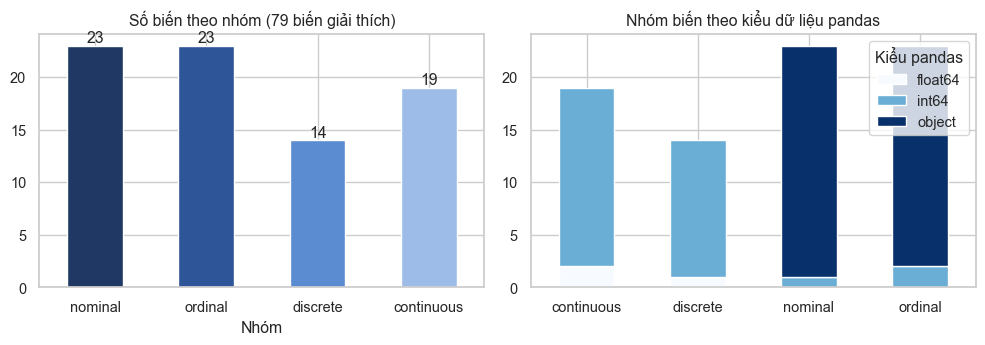

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
cnt.reindex(['nominal','ordinal','discrete','continuous']).plot.bar(ax=ax[0], color=['#1F3864','#2E5597','#5B8BD0','#9DBCE8'], rot=0)
ax[0].set_title('Số biến theo nhóm (79 biến giải thích)'); ax[0].bar_label(ax[0].containers[0])
pd.crosstab(vt.Nhóm, vt['Kiểu pandas']).plot.bar(stacked=True, ax=ax[1], rot=0, colormap='Blues')
ax[1].set_title('Nhóm biến theo kiểu dữ liệu pandas'); ax[1].set_xlabel('')
save_fig('01_nhom_bien')

**Lưu ý:** một số biến lưu dạng số nhưng bản chất là phân loại/định danh (`MSSubClass`) hoặc thứ bậc (`OverallQual`, `OverallCond`); `MoSold`, `YrSold` là rời rạc nhưng mang tính thời gian/mùa vụ. Không nên xem chúng là biến liên tục khi mô hình hóa.

In [5]:
coded = [c for c in feat if str(train[c].dtype) != 'object' and str(train[c].dtype)[:3] != 'str' and GROUP_OF[c] in ('nominal','ordinal')]
print('Biến lưu kiểu số nhưng là nominal/ordinal:', coded)

Biến lưu kiểu số nhưng là nominal/ordinal: ['MSSubClass', 'OverallQual', 'OverallCond']


## 3. Thống kê mô tả

In [6]:
num = [c for c in feat if GROUP_OF[c] in ('continuous','discrete')]
d = train[num + ['SalePrice']].describe().T
d['skew'] = train[num + ['SalePrice']].skew()
d.round(2).to_csv(f'{RES}/thong_ke_mo_ta_bien_so.csv', encoding='utf-8-sig')
display(d.round(2))

,count,mean,std,min,25%,50%,75%,max,skew
LotFrontage,1201.0,70.05,24.28,21.0,59.00,69.0,80.00,313.0,2.16
LotArea,1460.0,10516.83,9981.26,1300.0,7553.50,9478.5,11601.50,215245.0,12.21
YearBuilt,1460.0,1971.27,30.20,1872.0,1954.00,1973.0,2000.00,2010.0,-0.61
YearRemodAdd,1460.0,1984.87,20.65,1950.0,1967.00,1994.0,2004.00,2010.0,-0.50
MasVnrArea,1452.0,103.69,181.07,0.0,0.00,0.0,166.00,1600.0,2.67
BsmtFinSF1,1460.0,443.64,456.10,0.0,0.00,383.5,712.25,5644.0,1.69
BsmtFinSF2,1460.0,46.55,161.32,0.0,0.00,0.0,0.00,1474.0,4.26
BsmtUnfSF,1460.0,567.24,441.87,0.0,223.00,477.5,808.00,2336.0,0.92
TotalBsmtSF,1460.0,1057.43,438.71,0.0,795.75,991.5,1298.25,6110.0,1.52
1stFlrSF,1460.0,1162.63,386.59,334.0,882.00,1087.0,1391.25,4692.0,1.38


In [7]:
cat = [c for c in feat if GROUP_OF[c] in ('nominal','ordinal') and (str(train[c].dtype) == 'object' or str(train[c].dtype)[:3] == 'str')]
display(train[cat].describe().T.sort_values('unique', ascending=False).head(10))
print(train.SalePrice.describe())

,count,unique,top,freq
Neighborhood,1460,25,NAmes,225
Exterior2nd,1460,16,VinylSd,504
Exterior1st,1460,15,VinylSd,515
SaleType,1460,9,WD,1267
Condition1,1460,9,Norm,1260
Condition2,1460,8,Norm,1445
HouseStyle,1460,8,1Story,726
RoofMatl,1460,8,CompShg,1434
Functional,1460,7,Typ,1360
BsmtFinType2,1422,6,Unf,1256


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


## 4. So sánh dữ liệu trong paper và trong Kaggle

In [8]:
cmp = pd.DataFrame({'Tiêu chí': ['Số quan sát', 'Số biến giải thích', 'Nhóm biến (nominal/ordinal/discrete/continuous)', 'Neighborhood', 'Ghi chú'],
  'Paper De Cock (2011)': ['2930', '80 (+ PID, SalePrice)', '23 / 23 / 14 / 20 (gồm SalePrice)', '28 nhóm', 'Toàn bộ giao dịch 2006-2010'],
  'Kaggle (dữ liệu của nhóm)': [f'train {len(train)} + test {len(test)} = {len(train)+len(test)}', f'{len(feat)} (+ Id, SalePrice)',
     ' / '.join(str(cnt[k]) for k in ['nominal','ordinal','discrete','continuous']) + ' (+ SalePrice)', f'{train.Neighborhood.nunique()} nhóm trong train', 'Test không có SalePrice']})
display(cmp)
save_json('nb01', {'n_train': len(train), 'n_test': len(test), 'n_cols_train': train.shape[1], 'n_cols_test': test.shape[1], 'n_feat': len(feat),
  'groups': cnt.to_dict(), 'n_object': len(cat), 'coded_cat': coded, 'skew_saleprice': train.SalePrice.skew(), 'dup_rows': int(train.duplicated().sum()),
  'n_neigh_train': train.Neighborhood.nunique(), 'n_neigh_test': test.Neighborhood.nunique()})

,Tiêu chí,Paper De Cock (2011),Kaggle (dữ liệu của nhóm)
0,Số quan sát,2930,train 1460 + test 1459 = 2919
1,Số biến giải thích,"80 (+ PID, SalePrice)","79 (+ Id, SalePrice)"
2,Nhóm biến (nominal/ordinal/discrete/continuous),23 / 23 / 14 / 20 (gồm SalePrice),23 / 23 / 14 / 19 (+ SalePrice)
3,Neighborhood,28 nhóm,25 nhóm trong train
4,Ghi chú,Toàn bộ giao dịch 2006-2010,Test không có SalePrice


# 02 - Phân tích đơn biến (Univariate)
**Phụ trách: Nguyễn Thành Đại (TV2)**.

In [9]:
# (dùng lại cách nạp dữ liệu ở trên)
train, test = load()

In [10]:
feat = [c for c in train.columns if c not in ('Id','SalePrice')]
cont = CONTINUOUS; disc = DISCRETE
cats = [c for c in feat if GROUP_OF[c] in ('nominal','ordinal')]

## 1. Biến mục tiêu SalePrice

count      1460.00
mean     180921.20
std       79442.50
min       34900.00
25%      129975.00
50%      163000.00
75%      214000.00
max      755000.00
skew          1.88
kurt          6.54
Name: SalePrice, dtype: float64
Sau log1p: skew = 0.121 , kurt = 0.81


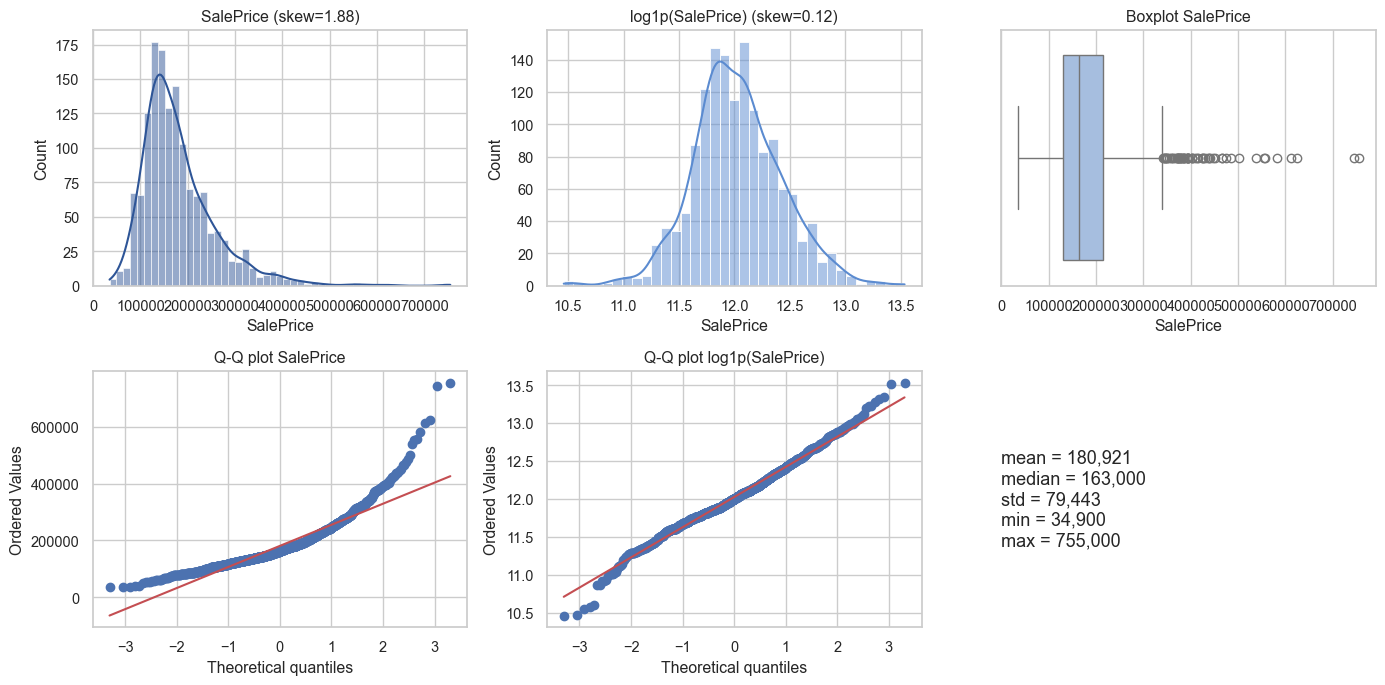

In [11]:
y = train.SalePrice
st = y.describe(); st['skew'] = y.skew(); st['kurt'] = y.kurt()
print(st.round(2)); print('Sau log1p: skew =', round(np.log1p(y).skew(), 3), ', kurt =', round(np.log1p(y).kurt(), 3))
from scipy import stats
fig, ax = plt.subplots(2, 3, figsize=(14, 7))
sns.histplot(y, kde=True, ax=ax[0,0], color='#2E5597'); ax[0,0].set_title(f'SalePrice (skew={y.skew():.2f})')
sns.histplot(np.log1p(y), kde=True, ax=ax[0,1], color='#5B8BD0'); ax[0,1].set_title(f'log1p(SalePrice) (skew={np.log1p(y).skew():.2f})')
sns.boxplot(x=y, ax=ax[0,2], color='#9DBCE8'); ax[0,2].set_title('Boxplot SalePrice')
stats.probplot(y, plot=ax[1,0]); ax[1,0].set_title('Q-Q plot SalePrice')
stats.probplot(np.log1p(y), plot=ax[1,1]); ax[1,1].set_title('Q-Q plot log1p(SalePrice)')
ax[1,2].axis('off'); ax[1,2].text(0, .5, f"mean = {y.mean():,.0f}\nmedian = {y.median():,.0f}\nstd = {y.std():,.0f}\nmin = {y.min():,.0f}\nmax = {y.max():,.0f}", fontsize=13, va='center')
save_fig('02_saleprice')

## 2. Biến liên tục

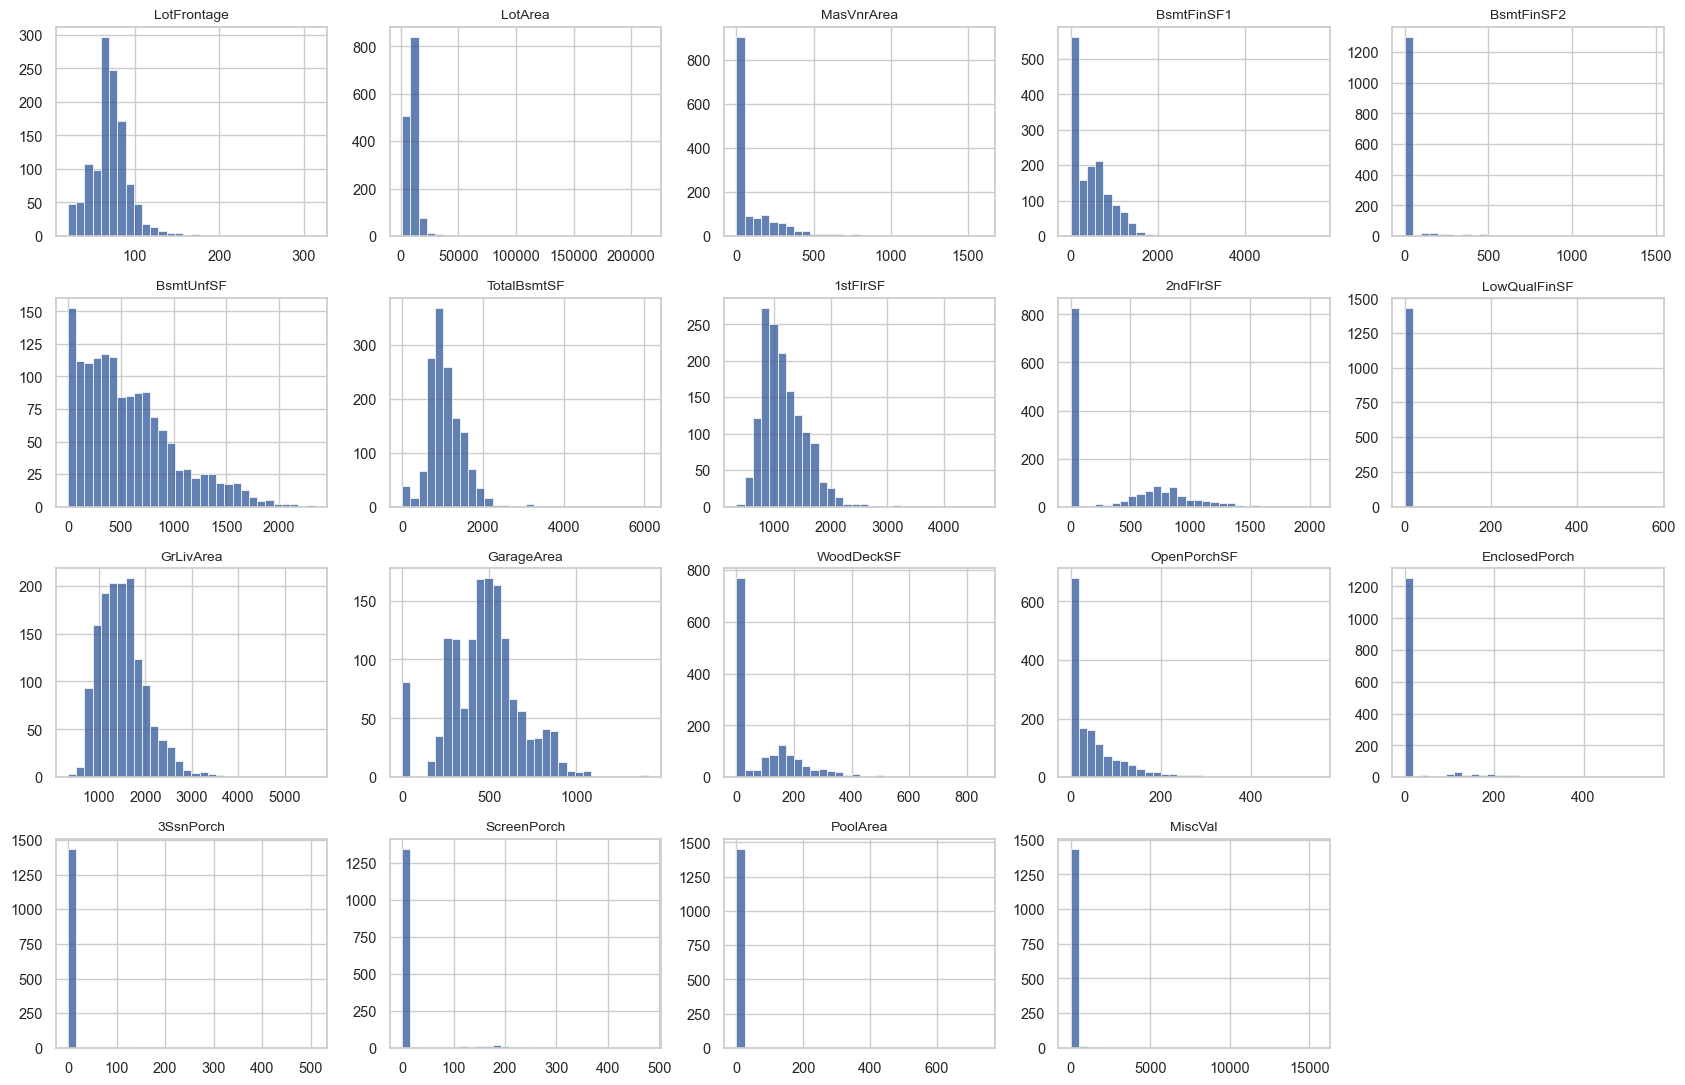

Tỉ lệ giá trị 0:
PoolArea         99.5
3SsnPorch        98.4
LowQualFinSF     98.2
MiscVal          96.4
ScreenPorch      92.1
BsmtFinSF2       88.6
EnclosedPorch    85.8
MasVnrArea       59.0
2ndFlrSF         56.8
WoodDeckSF       52.1
OpenPorchSF      44.9
BsmtFinSF1       32.0


In [12]:
fig, axes = plt.subplots(4, 5, figsize=(17, 11))
for a, c in zip(axes.ravel(), cont):
    sns.histplot(train[c].dropna(), bins=30, ax=a, color='#2E5597'); a.set_title(c, fontsize=10); a.set_xlabel(''); a.set_ylabel('')
axes.ravel()[-1].axis('off')
save_fig('02_lienTuc_hist')
zero = (train[cont] == 0).mean().sort_values(ascending=False)
sk = train[cont + disc].skew().sort_values(ascending=False)
print('Tỉ lệ giá trị 0:'); print((zero[zero > 0.3] * 100).round(1).to_string())

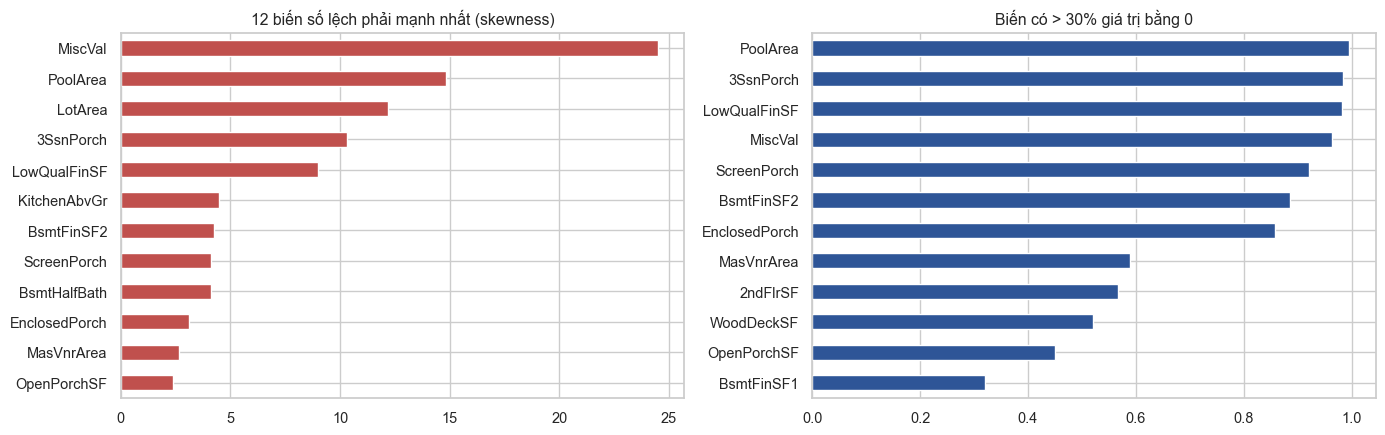

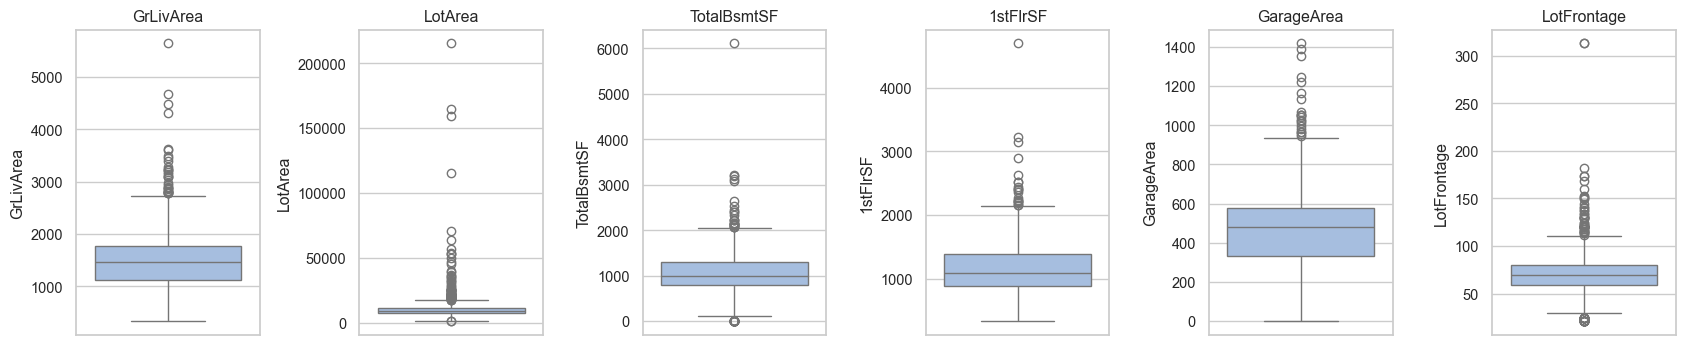

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sk.head(12).sort_values().plot.barh(ax=ax[0], color='#C0504D'); ax[0].set_title('12 biến số lệch phải mạnh nhất (skewness)')
zero[zero > 0.3].sort_values().plot.barh(ax=ax[1], color='#2E5597'); ax[1].set_title('Biến có > 30% giá trị bằng 0')
save_fig('02_skew_zero')
key = ['GrLivArea','LotArea','TotalBsmtSF','1stFlrSF','GarageArea','LotFrontage']
fig, axes = plt.subplots(1, 6, figsize=(17, 3.6))
for a, c in zip(axes, key): sns.boxplot(y=train[c], ax=a, color='#9DBCE8'); a.set_title(c)
save_fig('02_box_key')

## 3. Biến rời rạc

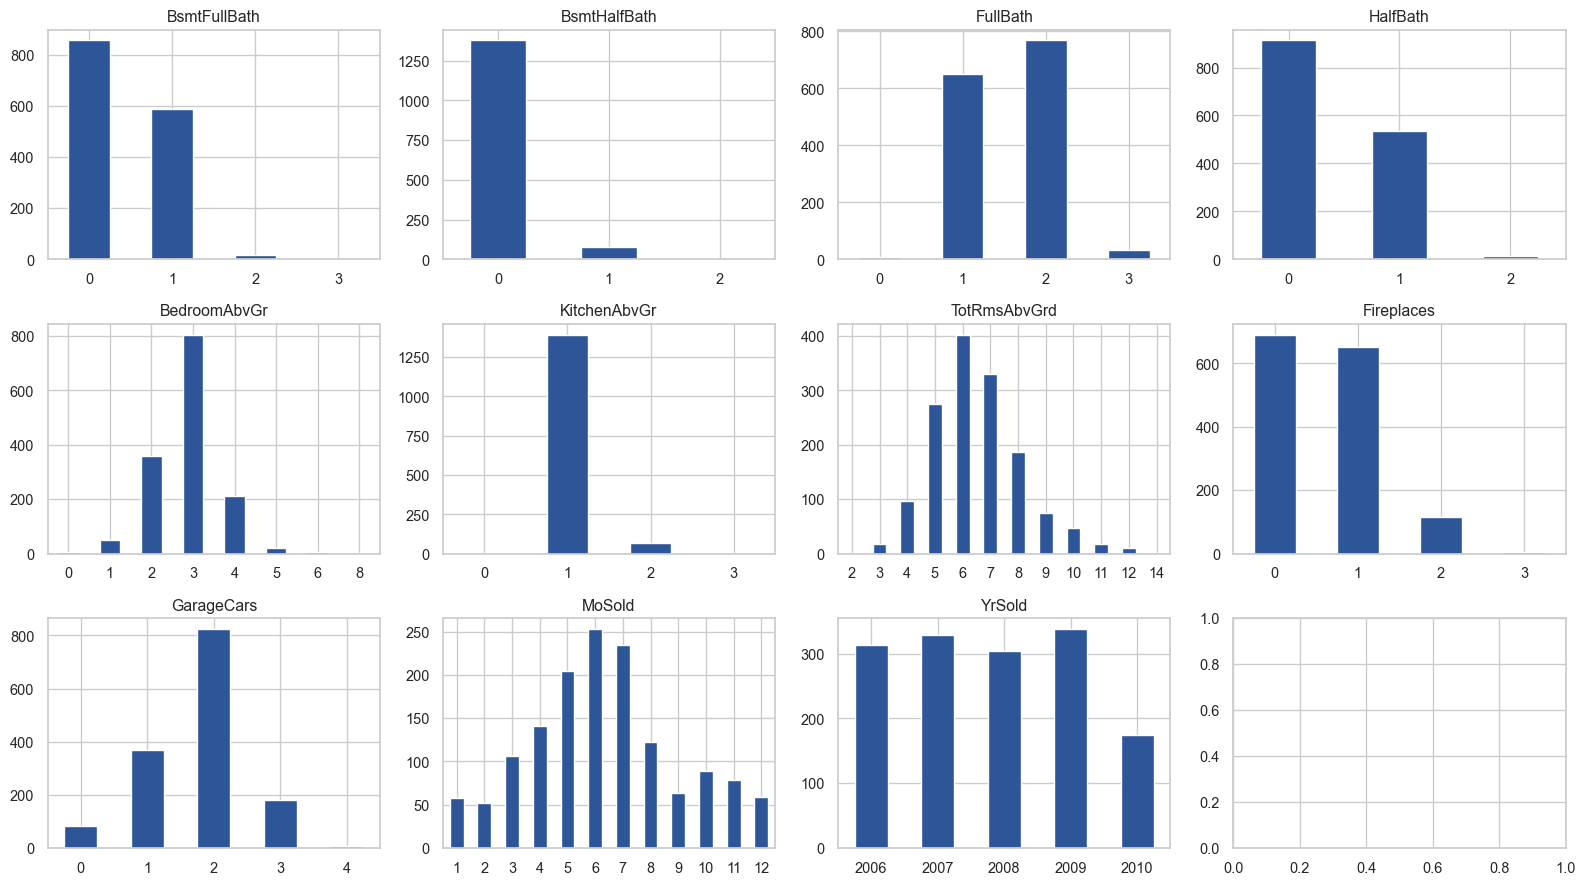

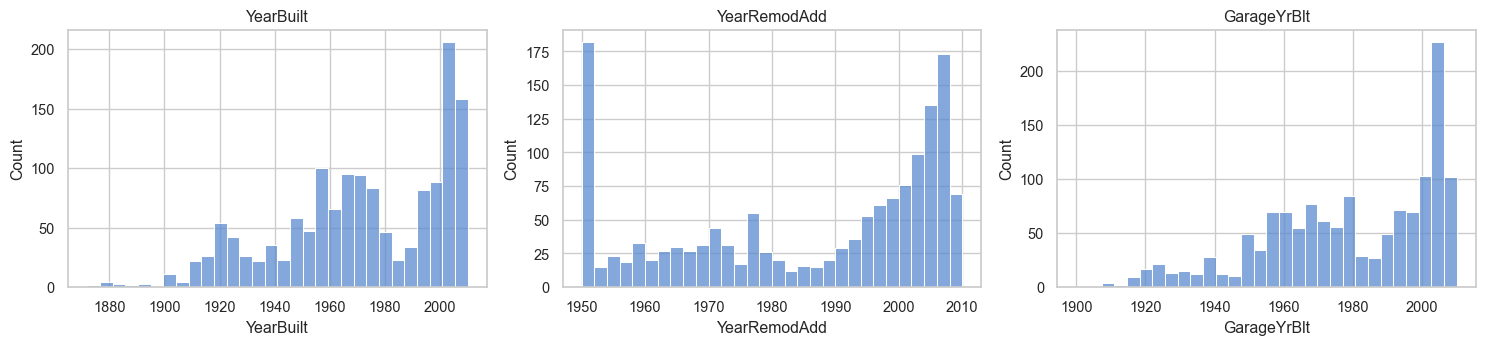

In [14]:
dc = [c for c in disc if c not in ('YearBuilt','YearRemodAdd','GarageYrBlt')]
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for a, c in zip(axes.ravel(), dc):
    train[c].value_counts().sort_index().plot.bar(ax=a, color='#2E5597', rot=0); a.set_title(c); a.set_xlabel('')
save_fig('02_rời_rạc')
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for a, c in zip(axes, ['YearBuilt','YearRemodAdd','GarageYrBlt']): sns.histplot(train[c].dropna(), bins=30, ax=a, color='#5B8BD0'); a.set_title(c)
save_fig('02_nam')

## 4. Biến phân loại (nominal + ordinal)

Biến gần như hằng số (>95% một giá trị):


,levels,top_share,top
Utilities,2,0.999,AllPub
Street,2,0.996,Pave
PoolQC,4,0.995,NaN
Condition2,8,0.990,Norm
RoofMatl,8,0.982,CompShg
Heating,6,0.978,GasA
MiscFeature,5,0.963,NaN


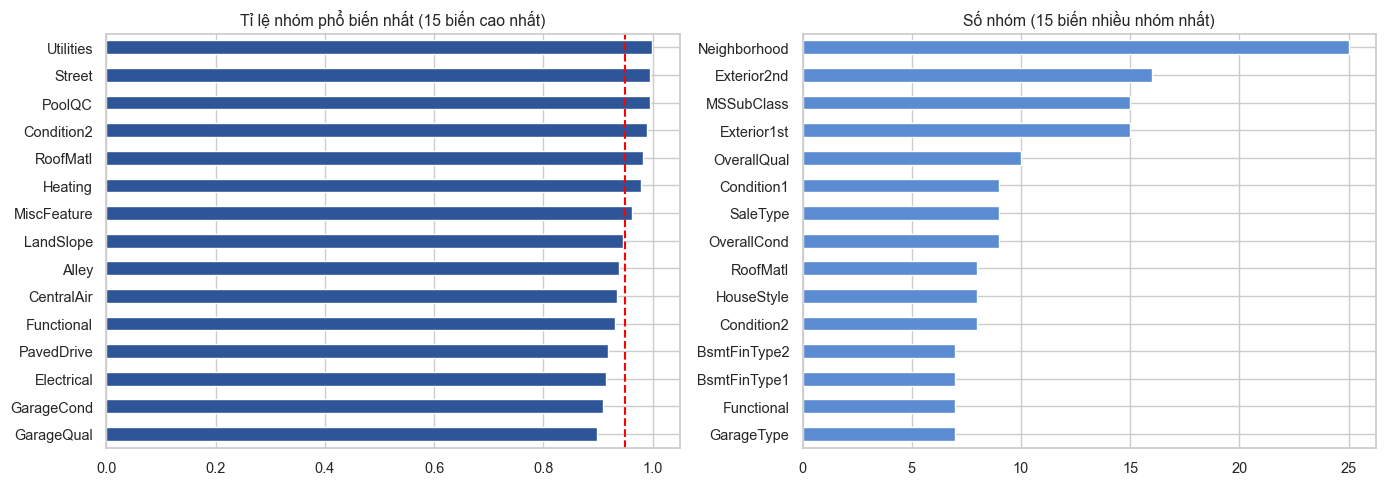

In [15]:
freq = pd.DataFrame({'levels': [train[c].nunique(dropna=False) for c in cats],
  'top_share': [train[c].value_counts(normalize=True, dropna=False).iloc[0] for c in cats],
  'top': [train[c].value_counts(dropna=False).index[0] for c in cats]}, index=cats)
near = freq[freq.top_share > 0.95].sort_values('top_share', ascending=False)
print('Biến gần như hằng số (>95% một giá trị):'); display(near.round(3))
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
freq.top_share.sort_values(ascending=False).head(15).sort_values().plot.barh(ax=ax[0], color='#2E5597'); ax[0].axvline(.95, color='red', ls='--')
ax[0].set_title('Tỉ lệ nhóm phổ biến nhất (15 biến cao nhất)')
freq.levels.sort_values(ascending=False).head(15).sort_values().plot.barh(ax=ax[1], color='#5B8BD0'); ax[1].set_title('Số nhóm (15 biến nhiều nhóm nhất)')
save_fig('02_cat_overview')

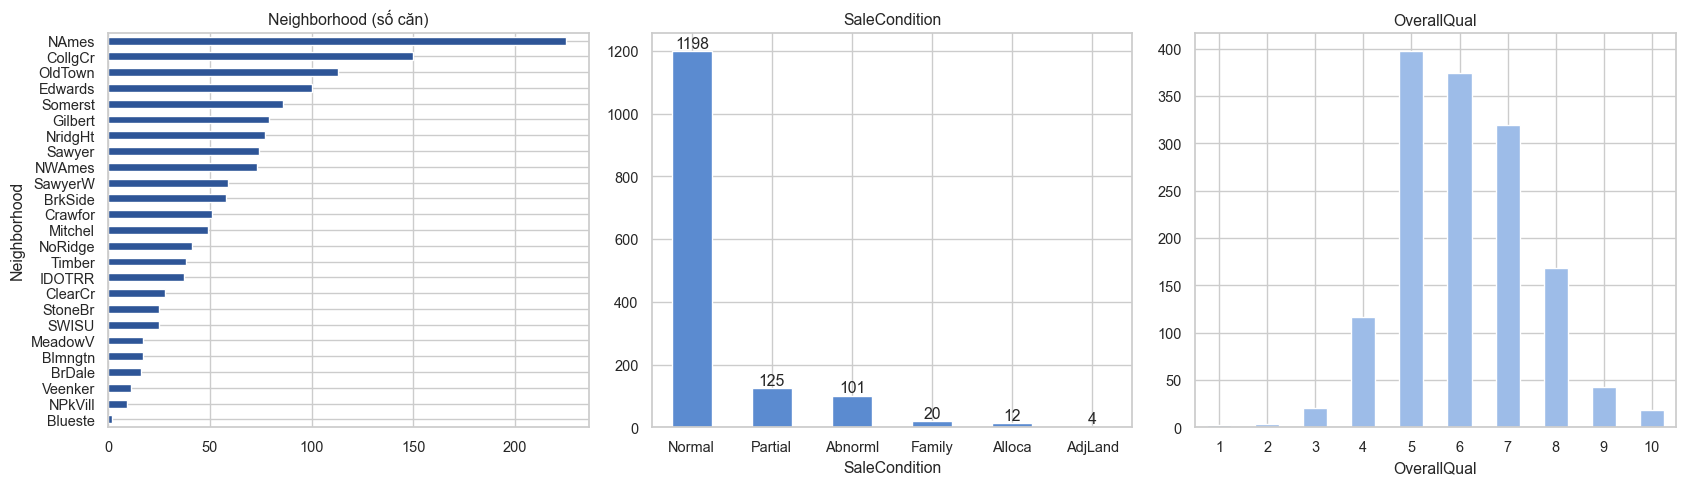

Số nhóm hiếm (<10 căn) lớn nhất: [('Condition2', 7), ('RoofMatl', 6), ('SaleType', 6), ('Exterior1st', 5), ('Exterior2nd', 5), ('Heating', 4), ('Condition1', 3), ('GarageCond', 3)]


In [16]:
fig, ax = plt.subplots(1, 3, figsize=(17, 5))
train.Neighborhood.value_counts().sort_values().plot.barh(ax=ax[0], color='#2E5597'); ax[0].set_title('Neighborhood (số căn)')
train.SaleCondition.value_counts().plot.bar(ax=ax[1], color='#5B8BD0', rot=0); ax[1].set_title('SaleCondition'); ax[1].bar_label(ax[1].containers[0])
train.OverallQual.value_counts().sort_index().plot.bar(ax=ax[2], color='#9DBCE8', rot=0); ax[2].set_title('OverallQual')
save_fig('02_cat_key')
rare = {c: int((train[c].value_counts() < 10).sum()) for c in cats}
print('Số nhóm hiếm (<10 căn) lớn nhất:', sorted(rare.items(), key=lambda kv: -kv[1])[:8])

In [17]:
ex = {'disc': {'fullbath_le2': (train.FullBath <= 2).mean(), 'bed3': (train.BedroomAbvGr == 3).mean(), 'kitchen1': (train.KitchenAbvGr == 1).mean(),
  'fire_le1': (train.Fireplaces <= 1).mean(), 'garagecars4': int((train.GarageCars == 4).sum()), 'yr_counts': train.YrSold.value_counts().sort_index().to_dict(),
  'mo_567': int(train.MoSold.between(5, 7).sum()), 'qual_5_7': (train.OverallQual.between(5, 7)).mean()}}
print(ex)
save_json('nb02', {**ex, 'sp': {k: float(v) for k, v in st.items()}, 'skew_log': np.log1p(y).skew(), 'kurt_log': np.log1p(y).kurt(),
  'top_skew': sk.head(8).round(1).to_dict(), 'zero': (zero[zero > 0.3] * 100).round(1).to_dict(), 'near_const': near.top_share.round(3).to_dict(),
  'n_near_const': len(near), 'neigh_top': train.Neighborhood.value_counts().head(3).to_dict(), 'neigh_bottom': train.Neighborhood.value_counts().tail(3).to_dict(),
  'salecond': train.SaleCondition.value_counts().to_dict(), 'rare_levels_total': int(sum(rare.values())), 'n_cats': len(cats)})

{'disc': {'fullbath_le2': np.float64(0.9773972602739726), 'bed3': np.float64(0.5506849315068493), 'kitchen1': np.float64(0.9534246575342465), 'fire_le1': np.float64(0.9178082191780822), 'garagecars4': 5, 'yr_counts': {2006: 314, 2007: 329, 2008: 304, 2009: 338, 2010: 175}, 'mo_567': 691, 'qual_5_7': np.float64(0.7465753424657534)}}


# 03 - Phân tích đa biến (Multivariate)
**Phụ trách: Nguyễn Xuân Hậu Thành (TV3)**.

In [18]:
# (dùng lại cách nạp dữ liệu ở trên)
train, test = load()

In [19]:
feat = [c for c in train.columns if c not in ('Id','SalePrice')]
numf = [c for c in feat if str(train[c].dtype)[:3] in ('int','flo')]
cats = [c for c in feat if c not in numf]
cor = train[numf + ['SalePrice']].corr()
cs = cor.SalePrice.drop('SalePrice').sort_values(ascending=False)
sp = train[numf + ['SalePrice']].corr(method='spearman').SalePrice.drop('SalePrice')

## 1. Tương quan với SalePrice

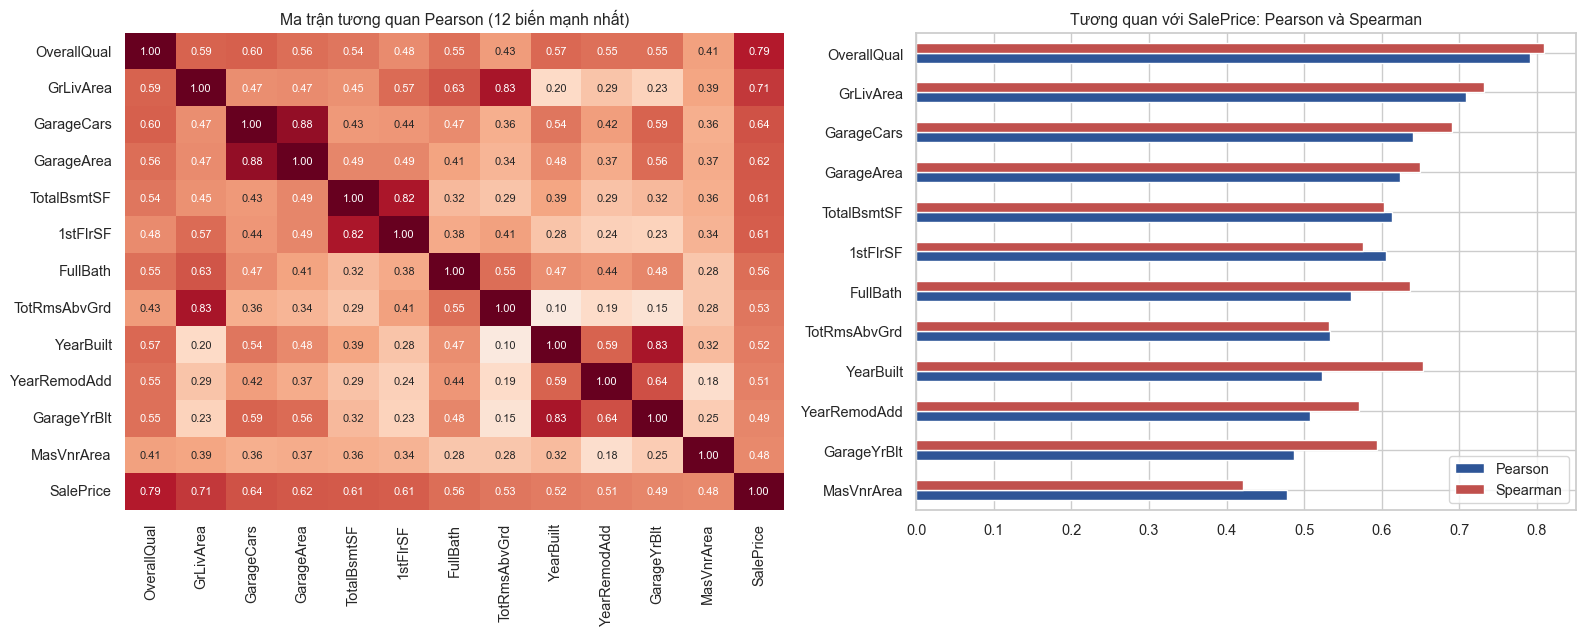

OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507
Âm mạnh nhất:
MSSubClass      -0.084
EnclosedPorch   -0.129
KitchenAbvGr    -0.136


In [20]:
top = cs.abs().sort_values(ascending=False).head(12).index.tolist()
fig, ax = plt.subplots(1, 2, figsize=(16, 6.5))
sns.heatmap(train[top + ['SalePrice']].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax[0], annot_kws={'size': 8}, cbar=False)
ax[0].set_title('Ma trận tương quan Pearson (12 biến mạnh nhất)')
t = pd.DataFrame({'Pearson': cs, 'Spearman': sp.reindex(cs.index)}).loc[top].sort_values('Pearson')
t.plot.barh(ax=ax[1], color=['#2E5597', '#C0504D']); ax[1].set_title('Tương quan với SalePrice: Pearson và Spearman')
save_fig('03_tuong_quan')
print(cs.head(10).round(3).to_string()); print('Âm mạnh nhất:'); print(cs.tail(3).round(3).to_string())

## 2. Đa cộng tuyến

Cặp |r| > 0.8: [('GarageCars', 'GarageArea', np.float64(0.882)), ('YearBuilt', 'GarageYrBlt', np.float64(0.826)), ('GrLivArea', 'TotRmsAbvGrd', np.float64(0.825)), ('TotalBsmtSF', '1stFlrSF', np.float64(0.82))]
LowQualFinSF    inf
BsmtFinSF1      inf
GrLivArea       inf
2ndFlrSF        inf
1stFlrSF        inf
TotalBsmtSF     inf
BsmtUnfSF       inf
BsmtFinSF2      inf
GarageCars      5.5
GarageArea      5.2


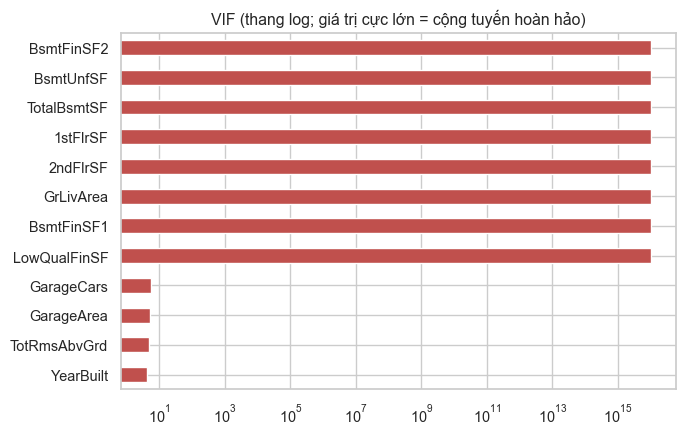

In [21]:
cf = train[numf].corr().abs(); pairs = []
cols = cf.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if cf.iloc[i, j] > 0.8: pairs.append((cols[i], cols[j], round(train[cols[i]].corr(train[cols[j]]), 3)))
pairs = sorted(pairs, key=lambda p: -abs(p[2])); print('Cặp |r| > 0.8:', pairs)
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
X = train[numf].fillna(train[numf].median()); X = X.loc[:, X.std() > 0]; X = X.drop(columns=['GarageYrBlt'], errors='ignore'); X.insert(0, 'const', 1.0)
V = pd.Series({c: vif(X.values, i) for i, c in enumerate(X.columns) if c != 'const'}).sort_values(ascending=False)
print(V.head(10).round(1).to_string())
V.head(12).replace(np.inf, 1e16).sort_values().plot.barh(figsize=(7, 4.5), color='#C0504D', logx=True, title='VIF (thang log; giá trị cực lớn = cộng tuyến hoàn hảo)')
save_fig('03_vif')

## 3. Quan hệ tuyến tính / phi tuyến với giá

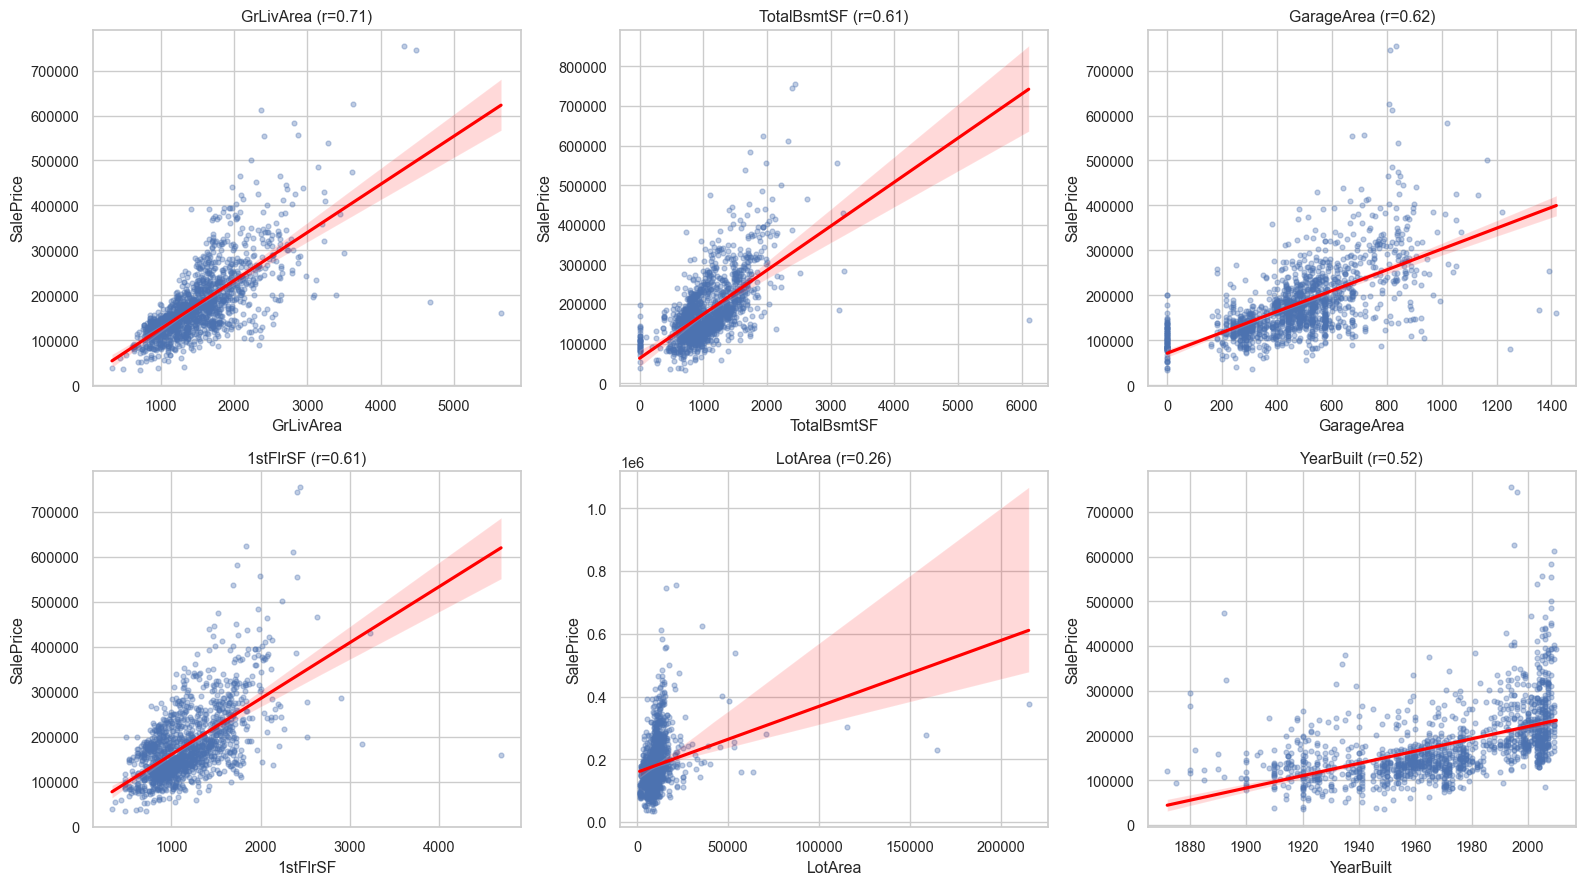

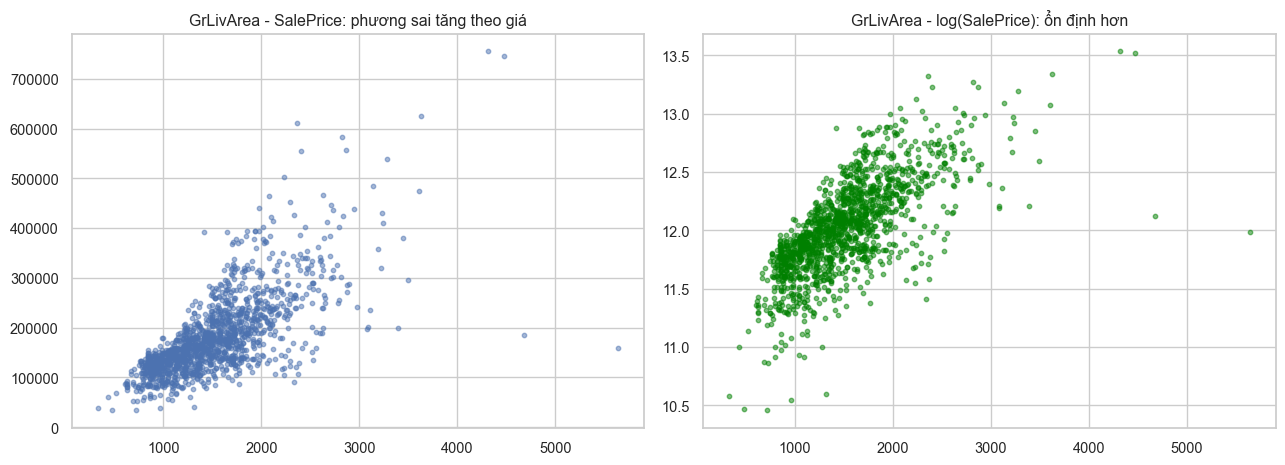

Spearman > Pearson (gợi ý phi tuyến/đơn điệu):
LotArea        0.193
OpenPorchSF    0.162
YearBuilt      0.130
GarageYrBlt    0.107
MSSubClass     0.091
FullBath       0.075


In [22]:
sc = ['GrLivArea','TotalBsmtSF','GarageArea','1stFlrSF','LotArea','YearBuilt']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for a, c in zip(axes.ravel(), sc):
    sns.regplot(data=train, x=c, y='SalePrice', ax=a, scatter_kws={'alpha': .35, 's': 12}, line_kws={'color': 'red'}, lowess=False); a.set_title(f'{c} (r={cs[c]:.2f})')
save_fig('03_scatter')
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
ax[0].scatter(train.GrLivArea, train.SalePrice, s=10, alpha=.5); ax[0].set_title('GrLivArea - SalePrice: phương sai tăng theo giá')
ax[1].scatter(train.GrLivArea, np.log(train.SalePrice), s=10, alpha=.5, color='green'); ax[1].set_title('GrLivArea - log(SalePrice): ổn định hơn')
save_fig('03_hetero')
diff = (sp - cs).sort_values(ascending=False); print('Spearman > Pearson (gợi ý phi tuyến/đơn điệu):'); print(diff.head(6).round(3).to_string())

## 4. Biến phân loại và SalePrice

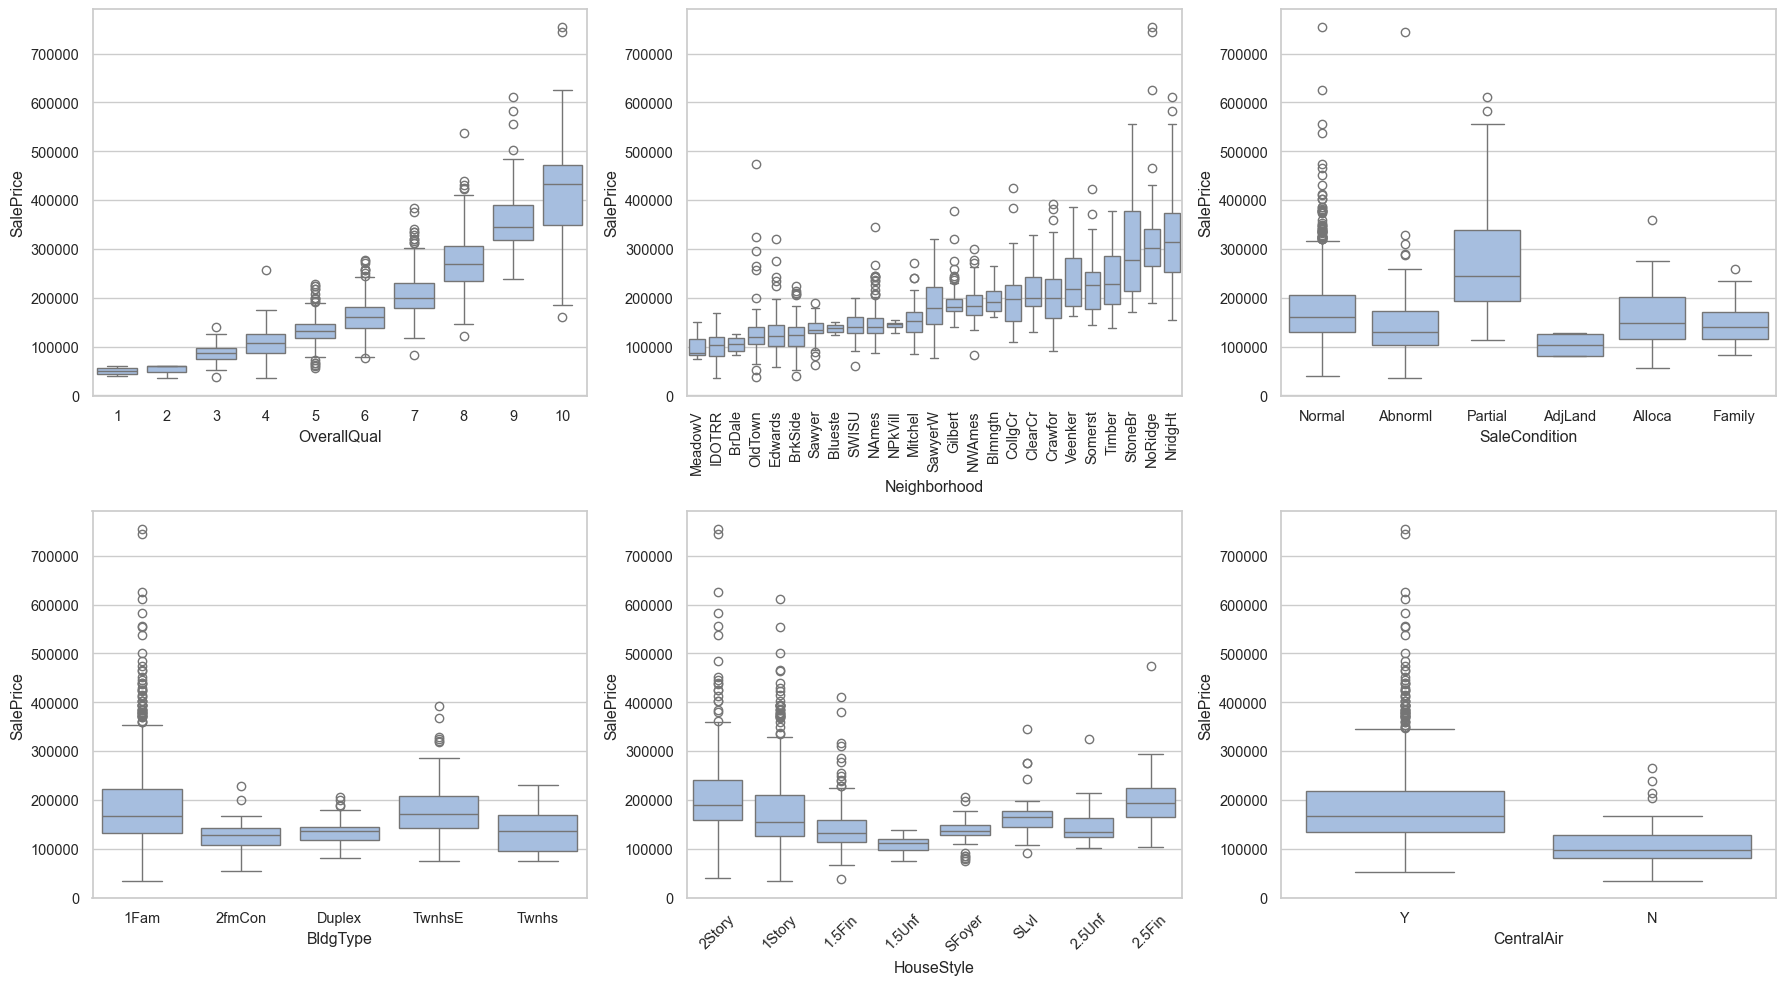

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sns.boxplot(data=train, x='OverallQual', y='SalePrice', ax=axes[0,0], color='#9DBCE8')
o = train.groupby('Neighborhood').SalePrice.median().sort_values().index
sns.boxplot(data=train, x='Neighborhood', y='SalePrice', order=o, ax=axes[0,1], color='#9DBCE8'); axes[0,1].tick_params(axis='x', rotation=90)
sns.boxplot(data=train, x='SaleCondition', y='SalePrice', ax=axes[0,2], color='#9DBCE8')
sns.boxplot(data=train, x='BldgType', y='SalePrice', ax=axes[1,0], color='#9DBCE8')
sns.boxplot(data=train, x='HouseStyle', y='SalePrice', ax=axes[1,1], color='#9DBCE8'); axes[1,1].tick_params(axis='x', rotation=45)
sns.boxplot(data=train, x='CentralAir', y='SalePrice', ax=axes[1,2], color='#9DBCE8')
save_fig('03_box_cat')

,H,p,eta2_xap_xi
Biến,,,
Neighborhood,868.532,0.0,0.595
ExterQual,683.440,0.0,0.468
KitchenQual,661.482,0.0,0.453
BsmtQual,631.833,0.0,0.433
GarageFinish,505.208,0.0,0.346
Foundation,488.723,0.0,0.335
GarageType,421.155,0.0,0.289
HeatingQC,354.672,0.0,0.243
Exterior1st,298.954,0.0,0.205


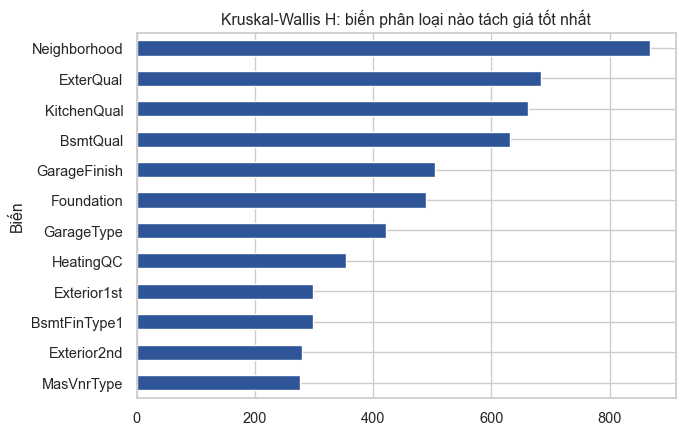

Biến phân loại KHÔNG có ý nghĩa (p>0.05): ['BsmtFinType2', 'LandSlope', 'Street', 'MiscFeature', 'PoolQC']


In [24]:
from scipy import stats
res = []
for c in cats:
    g = [v.SalePrice.values for _, v in train.dropna(subset=[c]).groupby(c) if len(v) > 1]
    if len(g) > 1:
        H_, p = stats.kruskal(*g); res.append((c, H_, p, H_ / (len(train) - 1)))
kw = pd.DataFrame(res, columns=['Biến', 'H', 'p', 'eta2_xap_xi']).sort_values('H', ascending=False).set_index('Biến')
kw.round(4).to_csv(f'{RES}/kruskal_bien_phan_loai.csv', encoding='utf-8-sig'); display(kw.head(10).round(3))
kw.head(12).sort_values('H').H.plot.barh(figsize=(7, 4.5), color='#2E5597', title='Kruskal-Wallis H: biến phân loại nào tách giá tốt nhất')
save_fig('03_kruskal')
print('Biến phân loại KHÔNG có ý nghĩa (p>0.05):', kw[kw.p > 0.05].index.tolist())

## 5. Biến gợi ý từ paper (TotalSF, tuổi nhà, tổng phòng tắm) và Figure 7

TotalSF        0.779
HouseAge      -0.523
TotalBath      0.632
GrLivArea      0.709
OverallQual    0.791
YearBuilt      0.523
FullBath       0.561


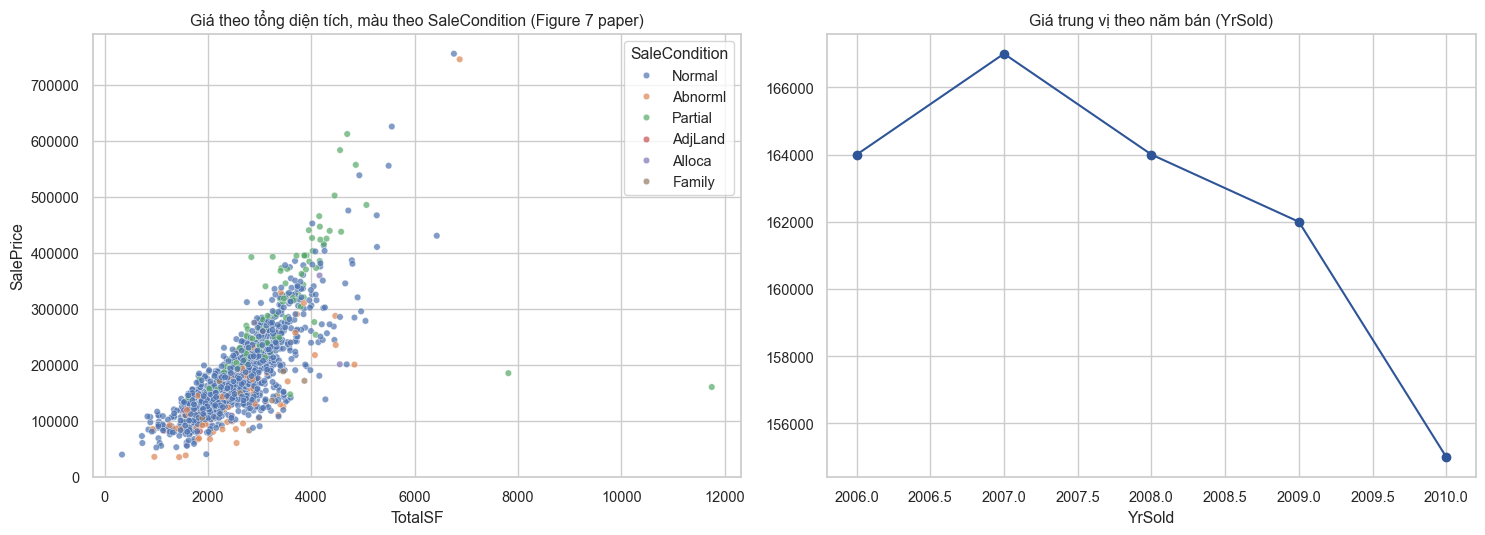

R2: GrLivArea=0.502; TotalSF=0.607; TotalSF+Neighborhood=0.758 (paper: khoảng 0.80)


In [25]:
d = train.copy()
d['TotalSF'] = d.TotalBsmtSF + d.GrLivArea; d['HouseAge'] = d.YrSold - d.YearBuilt
d['TotalBath'] = d.FullBath + 0.5 * d.HalfBath + d.BsmtFullBath + 0.5 * d.BsmtHalfBath
nc = d[['TotalSF','HouseAge','TotalBath','GrLivArea','OverallQual','YearBuilt','FullBath']].corrwith(d.SalePrice).round(3); print(nc.to_string())
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
sns.scatterplot(data=d, x='TotalSF', y='SalePrice', hue='SaleCondition', ax=ax[0], s=22, alpha=.7); ax[0].set_title('Giá theo tổng diện tích, màu theo SaleCondition (Figure 7 paper)')
d['SalePrice'].groupby(d.YrSold).median().plot(marker='o', ax=ax[1], color='#2E5597'); ax[1].set_title('Giá trung vị theo năm bán (YrSold)')
save_fig('03_totalsf')
m = smf = None
import statsmodels.formula.api as smf
r2_gr = smf.ols('SalePrice ~ GrLivArea', d).fit().rsquared; r2_tot = smf.ols('SalePrice ~ TotalSF', d).fit().rsquared
r2_nb = smf.ols('SalePrice ~ TotalSF + C(Neighborhood)', d).fit().rsquared
print(f'R2: GrLivArea={r2_gr:.3f}; TotalSF={r2_tot:.3f}; TotalSF+Neighborhood={r2_nb:.3f} (paper: khoảng 0.80)')

In [26]:
ex = {'yr_med': train.groupby('YrSold').SalePrice.median().to_dict(), 'vif_all': V.head(10).to_dict()}
print(ex)
save_json('nb03', {**ex, 'top_corr': cs.head(8).round(2).to_dict(), 'neg_corr': cs.tail(2).round(2).to_dict(), 'pairs': pairs, 'vif_top': V.head(6).round(1).replace(np.inf, None).to_dict(),
  'kw_top': kw.head(5).H.round(0).to_dict(), 'kw_ns': kw[kw.p > 0.05].index.tolist(), 'newvars': nc.to_dict(), 'r2': {'GrLivArea': r2_gr, 'TotalSF': r2_tot, 'TotalSF+Neighborhood': r2_nb},
  'spearman_gap': diff.head(4).round(2).to_dict(), 'neigh_med_hi': train.groupby('Neighborhood').SalePrice.median().sort_values().tail(3).to_dict(),
  'neigh_med_lo': train.groupby('Neighborhood').SalePrice.median().sort_values().head(3).to_dict(), 'salecond_med': train.groupby('SaleCondition').SalePrice.median().to_dict()})

{'yr_med': {2006: 163995.0, 2007: 167000.0, 2008: 164000.0, 2009: 162000.0, 2010: 155000.0}, 'vif_all': {'LowQualFinSF': inf, 'BsmtFinSF1': inf, 'GrLivArea': inf, '2ndFlrSF': inf, '1stFlrSF': inf, 'TotalBsmtSF': inf, 'BsmtUnfSF': inf, 'BsmtFinSF2': inf, 'GarageCars': 5.4950287544935055, 'GarageArea': 5.231135160761886}}


# 04 - Giá trị thiếu, mẫu bất thường và ngoại lệ
**Phụ trách: Lưu Lương Mạnh Dũng (TV4)**.

In [27]:
# (dùng lại cách nạp dữ liệu ở trên)
train, test = load()

## 1. Cảnh báo khi đọc file: chữ `None` bị pandas coi là thiếu
Trong `MasVnrType`, `None` (không ốp tường) là một nhóm hợp lệ. Với `pd.read_csv` mặc định (pandas >= 2.0), chữ 'None' bị coi là NaN nên cột này báo thiếu ~60%.

In [28]:
bad = pd.read_csv(f'{DATA}/train.csv')                       # cách đọc mặc định
print('Đọc mặc định   : MasVnrType thiếu =', bad.MasVnrType.isna().sum(), f'({bad.MasVnrType.isna().mean():.1%}); mode =', bad.MasVnrType.mode()[0])
print('Đọc đúng cách  : MasVnrType thiếu =', train.MasVnrType.isna().sum(), f'({train.MasVnrType.isna().mean():.1%}); giá trị:', train.MasVnrType.value_counts().to_dict())
print('=> Điền mode với cách đọc mặc định sẽ biến ~864 căn "None" thành "BrkFace" (sai).')

Đọc mặc định   : MasVnrType thiếu = 872 (59.7%); mode = BrkFace
Đọc đúng cách  : MasVnrType thiếu = 8 (0.5%); giá trị: {'None': 864, 'BrkFace': 445, 'Stone': 128, 'BrkCmn': 15}
=> Điền mode với cách đọc mặc định sẽ biến ~864 căn "None" thành "BrkFace" (sai).


## 2. Thống kê giá trị thiếu (train và test)

In [29]:
def miss(df):
    m = df.isna().sum(); m = m[m > 0].sort_values(ascending=False)
    return pd.DataFrame({'thieu': m, 'ty_le_%': (m / len(df) * 100).round(1)})
mt, ms = miss(train), miss(test)
mt['Nhóm'] = ['NA = không có' if c in NA_MEANS_NONE else ('Đi kèm không có garage' if c == 'GarageYrBlt' else 'Thiếu thật (cần điền)') for c in mt.index]
display(mt); print('Test: số cột thiếu =', len(ms), '| train:', len(mt))
mt.to_csv(f'{RES}/thieu_train.csv', encoding='utf-8-sig'); ms.to_csv(f'{RES}/thieu_test.csv', encoding='utf-8-sig')

,thieu,ty_le_%,Nhóm
PoolQC,1453,99.5,NA = không có
MiscFeature,1406,96.3,NA = không có
Alley,1369,93.8,NA = không có
Fence,1179,80.8,NA = không có
FireplaceQu,690,47.3,NA = không có
LotFrontage,259,17.7,Thiếu thật (cần điền)
GarageType,81,5.5,NA = không có
GarageYrBlt,81,5.5,Đi kèm không có garage
GarageFinish,81,5.5,NA = không có
GarageQual,81,5.5,NA = không có


Test: số cột thiếu = 33 | train: 19


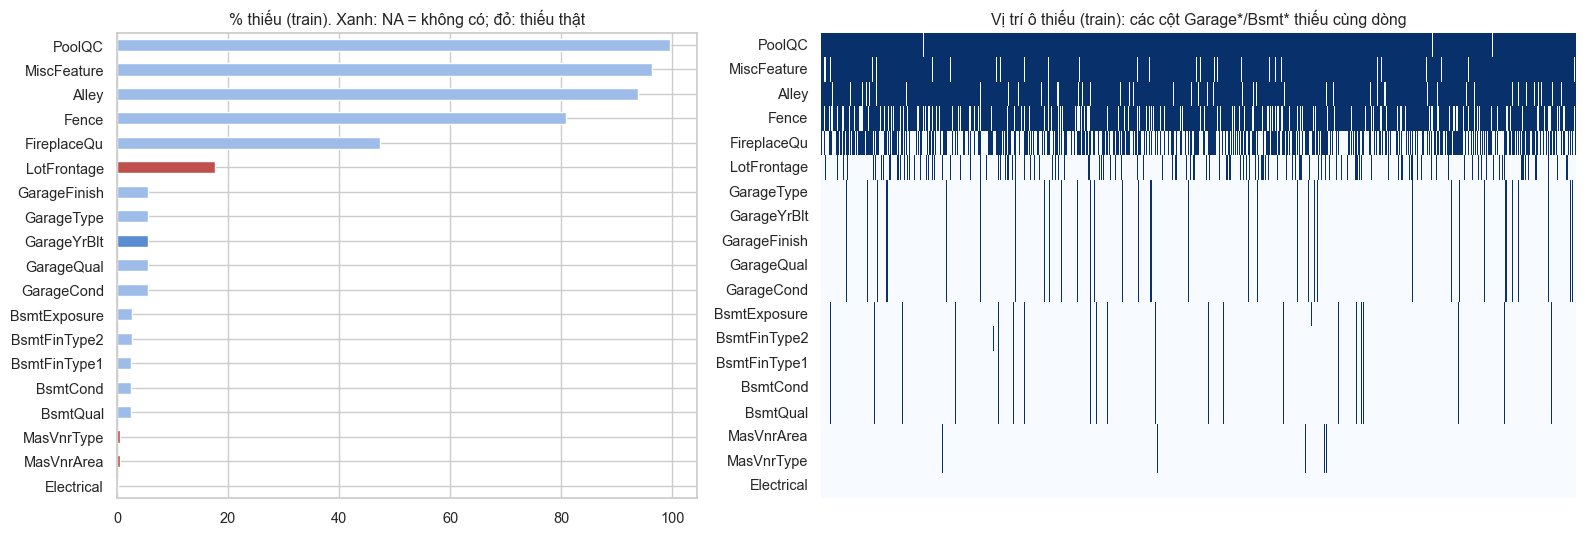

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={'width_ratios': [1, 1.3]})
colr = mt.Nhóm.map({'NA = không có': '#9DBCE8', 'Đi kèm không có garage': '#5B8BD0', 'Thiếu thật (cần điền)': '#C0504D'})
mt['ty_le_%'].sort_values().plot.barh(ax=ax[0], color=colr.reindex(mt['ty_le_%'].sort_values().index)); ax[0].set_title('% thiếu (train). Xanh: NA = không có; đỏ: thiếu thật')
sns.heatmap(train[mt.index].isna().T, cbar=False, ax=ax[1], xticklabels=False, cmap='Blues'); ax[1].set_title('Vị trí ô thiếu (train): các cột Garage*/Bsmt* thiếu cùng dòng')
save_fig('04_thieu')

## 3. Thiếu có ý nghĩa hay thiếu thật? Kiểm tra bằng quy tắc

In [31]:
def rules(df):
    g = df[['GarageType','GarageFinish','GarageQual','GarageCond','GarageYrBlt']]
    b = df[['BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2']]
    return {
     'Garage*: NA nhưng GarageArea>0 (thiếu thật)': int(((df.GarageArea > 0) & g.isna().any(axis=1)).sum()),
     'Garage*: NA hoàn toàn nhưng GarageArea=0/NaN (hợp lệ)': int(g.isna().all(axis=1).sum()),
     'Garage*: 5 cột thiếu cùng một dòng (tất cả hoặc không)': int((g.isna().sum(axis=1).isin([0, 5])).sum()),
     'Bsmt*: NA nhưng TotalBsmtSF>0 (thiếu thật)': int(((df.TotalBsmtSF > 0) & b.isna().any(axis=1)).sum()),
     'FireplaceQu NA nhưng Fireplaces>0': int(((df.Fireplaces > 0) & df.FireplaceQu.isna()).sum()),
     'FireplaceQu NA và Fireplaces=0 (hợp lệ)': int(((df.Fireplaces == 0) & df.FireplaceQu.isna()).sum()),
     'PoolQC NA nhưng PoolArea>0 (thiếu thật)': int(((df.PoolArea > 0) & df.PoolQC.isna()).sum()),
     'MasVnrType NA (thiếu thật, đi cùng MasVnrArea NA)': int(df.MasVnrType.isna().sum())}
rt = pd.DataFrame({'train': rules(train), 'test': rules(test)}); display(rt); rt.to_csv(f'{RES}/quy_tac_thieu.csv', encoding='utf-8-sig')
lf = train.groupby('Neighborhood').LotFrontage.agg(['count', 'median', lambda s: s.isna().sum()]); lf.columns = ['co_gia_tri', 'median', 'thieu']
print('LotFrontage thiếu theo Neighborhood (5 nơi nhiều nhất):'); display(lf.sort_values('thieu', ascending=False).head(5))

,train,test
Garage*: NA nhưng GarageArea>0 (thiếu thật),0,1
Garage*: NA hoàn toàn nhưng GarageArea=0/NaN (hợp lệ),81,76
Garage*: 5 cột thiếu cùng một dòng (tất cả hoặc không),1460,1457
Bsmt*: NA nhưng TotalBsmtSF>0 (thiếu thật),2,7
FireplaceQu NA nhưng Fireplaces>0,0,0
FireplaceQu NA và Fireplaces=0 (hợp lệ),690,730
PoolQC NA nhưng PoolArea>0 (thiếu thật),0,3
"MasVnrType NA (thiếu thật, đi cùng MasVnrArea NA)",8,16


LotFrontage thiếu theo Neighborhood (5 nơi nhiều nhất):


,co_gia_tri,median,thieu
Neighborhood,,,
NAmes,186,73.0,39
Gilbert,49,65.0,30
NWAmes,45,80.0,28
Sawyer,48,71.0,26
CollgCr,126,70.0,24


## 4. Mẫu bất thường (kiểm tra logic)

In [32]:
def logic(df):
    return {
     'YearRemodAdd < YearBuilt': int((df.YearRemodAdd < df.YearBuilt).sum()),
     'YrSold < YearBuilt': int((df.YrSold < df.YearBuilt).sum()),
     'GarageYrBlt > YrSold': int((df.GarageYrBlt > df.YrSold).sum()),
     'GarageYrBlt > 2010 (năm không thể có)': int((df.GarageYrBlt > 2010).sum()),
     'GarageYrBlt < YearBuilt (garage cũ hơn nhà)': int((df.GarageYrBlt < df.YearBuilt).sum()),
     '1stFlr+2ndFlr+LowQual != GrLivArea': int(((df['1stFlrSF'] + df['2ndFlrSF'] + df.LowQualFinSF) != df.GrLivArea).sum()),
     'BsmtFin1+Fin2+Unf != TotalBsmtSF': int(((df.BsmtFinSF1 + df.BsmtFinSF2 + df.BsmtUnfSF) != df.TotalBsmtSF).sum()),
     'MasVnrType=None nhưng MasVnrArea>0': int(((df.MasVnrType == 'None') & (df.MasVnrArea > 0)).sum()),
     'MasVnrType khác None nhưng MasVnrArea=0': int(((df.MasVnrType.notna()) & (df.MasVnrType != 'None') & (df.MasVnrArea == 0)).sum()),
     'BedroomAbvGr=0': int((df.BedroomAbvGr == 0).sum()),
     'GrLivArea > 4000': int((df.GrLivArea > 4000).sum())}
lg = pd.DataFrame({'train': logic(train), 'test': logic(test)}); display(lg); lg.to_csv(f'{RES}/kiem_tra_logic.csv', encoding='utf-8-sig')
print(test.loc[test.GarageYrBlt > 2010, ['Id','YearBuilt','GarageYrBlt','YrSold']])

,train,test
YearRemodAdd < YearBuilt,0,1
YrSold < YearBuilt,0,1
GarageYrBlt > YrSold,0,2
GarageYrBlt > 2010 (năm không thể có),0,1
GarageYrBlt < YearBuilt (garage cũ hơn nhà),9,9
1stFlr+2ndFlr+LowQual != GrLivArea,0,0
BsmtFin1+Fin2+Unf != TotalBsmtSF,0,1
MasVnrType=None nhưng MasVnrArea>0,5,2
MasVnrType khác None nhưng MasVnrArea=0,2,1
BedroomAbvGr=0,6,2


        Id  YearBuilt  GarageYrBlt  YrSold
1132  2593       2006       2207.0    2007


In [33]:
feat = [c for c in train.columns if c not in ('Id','SalePrice')]
cats = [c for c in feat if str(train[c].dtype)[:3] not in ('int','flo')]
rare = {c: [k for k, v in train[c].value_counts().items() if v < 0.01 * len(train)] for c in cats}
unseen = {c: sorted(set(test[c].dropna()) - set(train[c].dropna())) for c in cats}; unseen = {k: v for k, v in unseen.items() if v}
print('Số nhóm hiếm (<1% dòng) tổng cộng:', sum(len(v) for v in rare.values()), 'ở', sum(1 for v in rare.values() if v), 'biến')
print('Nhóm chỉ có trong test (không có trong train):', unseen)
from scipy import stats
numf = [c for c in feat if c not in cats]
ks = pd.Series({c: stats.ks_2samp(train[c].dropna(), test[c].dropna()).pvalue for c in numf}).sort_values()
print('Biến số có phân phối train/test khác nhau (KS p<0.01):', ks[ks < 0.01].round(4).to_dict())

Số nhóm hiếm (<1% dòng) tổng cộng: 85 ở 31 biến
Nhóm chỉ có trong test (không có trong train): {}
Biến số có phân phối train/test khác nhau (KS p<0.01): {}


## 5. Ngoại lệ

Train: GrLivArea > 4000 -> 4 dòng


,Id,GrLivArea,TotalBsmtSF,OverallQual,SaleCondition,SalePrice
523,524,4676,3138,10,Partial,184750
691,692,4316,2444,10,Normal,755000
1182,1183,4476,2396,10,Abnorml,745000
1298,1299,5642,6110,10,Partial,160000


Test: GrLivArea > 4000 -> 1 dòng, Id = [2550]


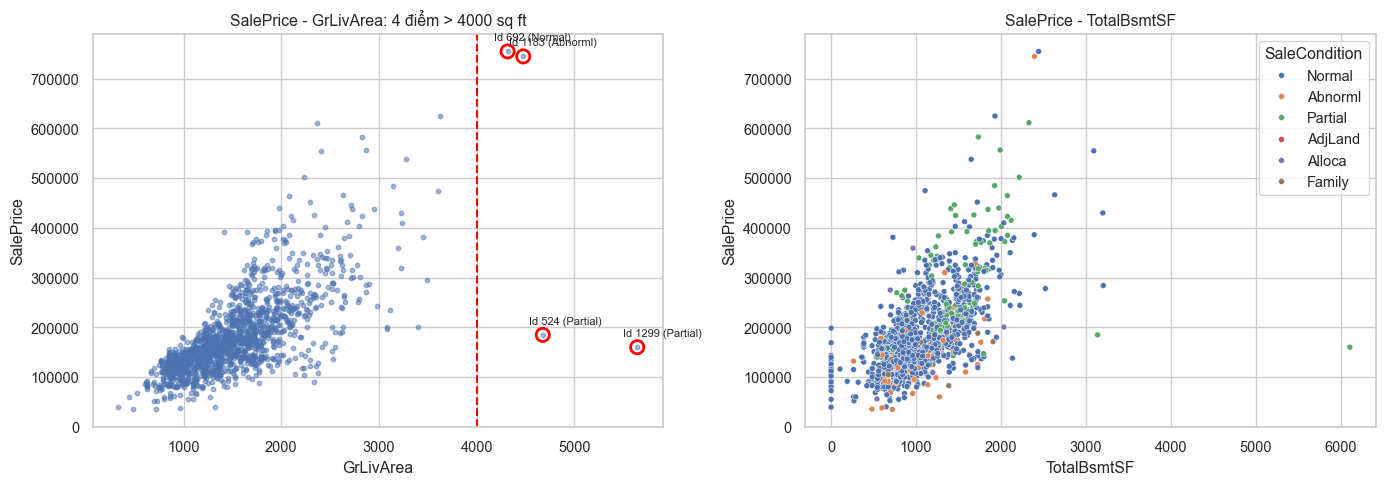

In [34]:
big = train[train.GrLivArea > 4000][['Id','GrLivArea','TotalBsmtSF','OverallQual','SaleCondition','SalePrice']]
print('Train: GrLivArea > 4000 ->', len(big), 'dòng'); display(big); print('Test: GrLivArea > 4000 ->', int((test.GrLivArea > 4000).sum()), 'dòng, Id =', test.loc[test.GrLivArea > 4000, 'Id'].tolist())
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(train.GrLivArea, train.SalePrice, s=10, alpha=.5); ax[0].scatter(big.GrLivArea, big.SalePrice, s=90, facecolors='none', edgecolors='red', lw=2)
for _, r in big.iterrows(): ax[0].annotate(f"Id {int(r.Id)} ({r.SaleCondition})", (r.GrLivArea, r.SalePrice), textcoords='offset points', xytext=(-10, 8), fontsize=8)
ax[0].axvline(4000, color='red', ls='--'); ax[0].set_title('SalePrice - GrLivArea: 4 điểm > 4000 sq ft'); ax[0].set_xlabel('GrLivArea'); ax[0].set_ylabel('SalePrice')
sns.scatterplot(data=train, x='TotalBsmtSF', y='SalePrice', hue='SaleCondition', ax=ax[1], s=18); ax[1].set_title('SalePrice - TotalBsmtSF')
save_fig('04_ngoai_le_scatter')

,IQR,Z>3
SalePrice,61,22
GrLivArea,31,16
LotArea,69,13
TotalBsmtSF,61,10
1stFlrSF,20,12
GarageArea,21,7
LotFrontage,88,12
MasVnrArea,96,32
BsmtFinSF1,7,6
WoodDeckSF,32,22


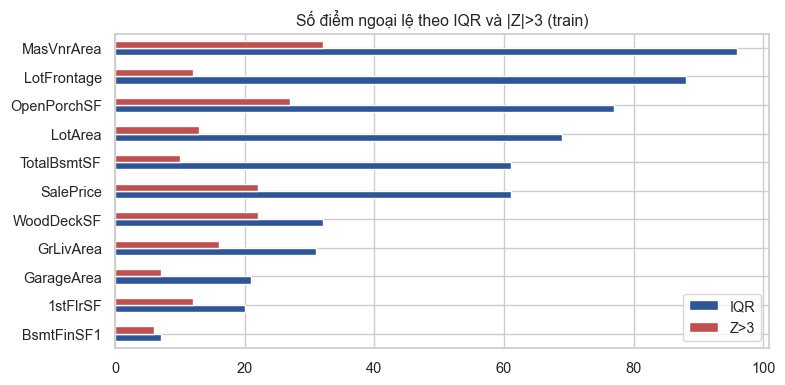

In [35]:
def iqr_out(s):
    q1, q3 = s.quantile([.25, .75]); i = q3 - q1; return int(((s < q1 - 1.5 * i) | (s > q3 + 1.5 * i)).sum())
cols = ['SalePrice','GrLivArea','LotArea','TotalBsmtSF','1stFlrSF','GarageArea','LotFrontage','MasVnrArea','BsmtFinSF1','WoodDeckSF','OpenPorchSF']
z = ((train[cols] - train[cols].mean()) / train[cols].std()).abs()
ot = pd.DataFrame({'IQR': {c: iqr_out(train[c].dropna()) for c in cols}, 'Z>3': (z > 3).sum()}); display(ot)
fig, ax = plt.subplots(1, 1, figsize=(8, 4)); ot.sort_values('IQR').plot.barh(ax=ax, color=['#2E5597', '#C0504D']); ax.set_title('Số điểm ngoại lệ theo IQR và |Z|>3 (train)')
save_fig('04_ngoai_le_iqr')

Cook > 4/n = 0.0027: 82 điểm


,Id,GrLivArea,OverallQual,SaleCondition,SalePrice,cooks,stud
1298,1299,5642,10,Partial,160000,4.794,-14.344
523,524,4676,10,Partial,184750,0.445,-9.073
916,917,480,2,Abnorml,35311,0.021,-4.016
495,496,720,4,Abnorml,34900,0.020,-4.886
676,677,1774,4,Normal,87000,0.017,-2.567
30,31,1317,4,Normal,40000,0.015,-5.390
968,969,968,3,Abnorml,37900,0.014,-3.919
1062,1063,2337,5,Normal,90000,0.014,-2.925
457,458,1663,4,Normal,256000,0.012,3.434
728,729,1776,5,Abnorml,110000,0.012,-2.942


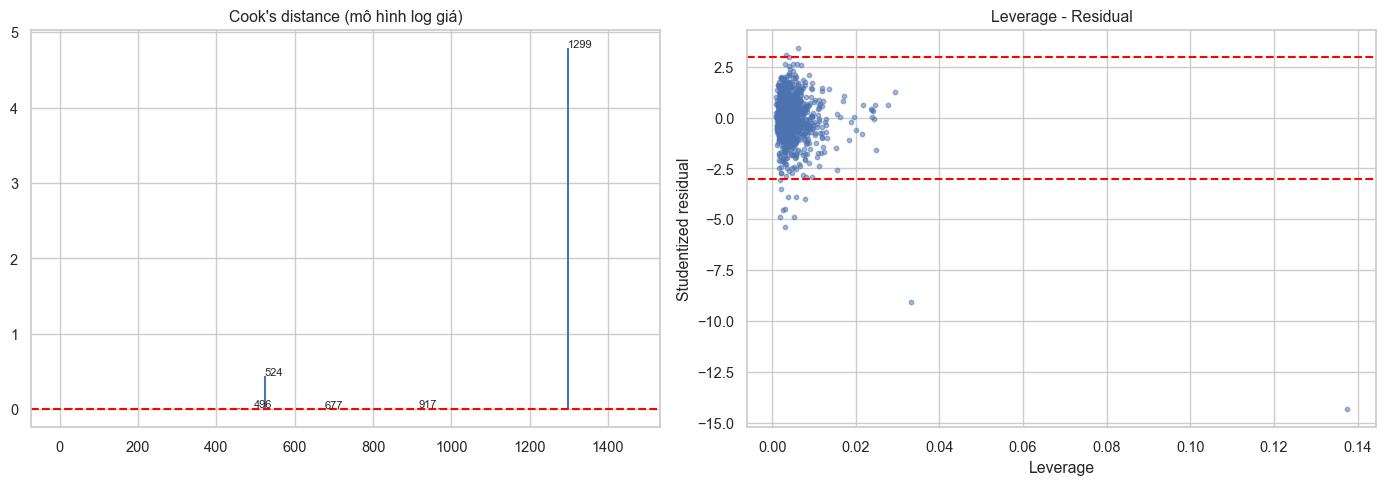

In [36]:
import statsmodels.formula.api as smf
fm = 'np.log(SalePrice) ~ GrLivArea + OverallQual + TotalBsmtSF + GarageCars + YearBuilt'
m = smf.ols(fm, train).fit(); inf = m.get_influence()
tr = train.assign(cooks=inf.cooks_distance[0], lev=inf.hat_matrix_diag, stud=inf.resid_studentized_external)
thr = 4 / len(tr); top = tr.sort_values('cooks', ascending=False).head(10)[['Id','GrLivArea','OverallQual','SaleCondition','SalePrice','cooks','stud']]
print(f'Cook > 4/n = {thr:.4f}: {(tr.cooks > thr).sum()} điểm'); display(top.round(3))
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].stem(tr.index, tr.cooks, markerfmt=' ', basefmt=' '); ax[0].axhline(thr, color='red', ls='--'); ax[0].set_title("Cook's distance (mô hình log giá)")
for _, r in top.head(5).iterrows(): ax[0].annotate(int(r.Id), (tr.index[tr.Id == r.Id][0], r.cooks), fontsize=8)
ax[1].scatter(tr.lev, tr.stud, s=10, alpha=.5); ax[1].set_xlabel('Leverage'); ax[1].set_ylabel('Studentized residual'); ax[1].set_title('Leverage - Residual'); ax[1].axhline(3, color='red', ls='--'); ax[1].axhline(-3, color='red', ls='--')
save_fig('04_cooks')

In [37]:
clean = train[train.GrLivArea <= 4000]
def fit(df, f): r = smf.ols(f, df).fit(); return r
a = fit(train, 'SalePrice ~ GrLivArea'); b = fit(clean, 'SalePrice ~ GrLivArea'); a2 = fit(train, fm); b2 = fit(clean, fm)
cmp = pd.DataFrame({'Số dòng': [len(train), len(clean)], 'R2 (GrLivArea)': [a.rsquared, b.rsquared], 'Hệ số GrLivArea': [a.params['GrLivArea'], b.params['GrLivArea']],
                    'R2 (log giá, 5 biến)': [a2.rsquared, b2.rsquared]}, index=['Trước khi loại', 'Sau khi loại 4 điểm']); display(cmp.round(4))
ex = {'miss_count': mt['thieu'].to_dict(), 'n_rare_vars': int(sum(1 for v in rare.values() if v)), 'thr_cook': thr, 'n_train': len(train), 'n_clean': len(clean)}
print(ex)
save_json('nb04', {**ex, 'masvn_default_na': int(bad.MasVnrType.isna().sum()), 'masvn_default_pct': float(bad.MasVnrType.isna().mean() * 100), 'masvn_mode_bad': bad.MasVnrType.mode()[0],
  'masvn_true_na': int(train.MasVnrType.isna().sum()), 'masvn_none': int((train.MasVnrType == 'None').sum()), 'miss_train': mt['ty_le_%'].to_dict(), 'miss_group': mt.Nhóm.value_counts().to_dict(),
  'n_miss_cols_train': len(mt), 'n_miss_cols_test': len(ms), 'rules': rt.to_dict(), 'logic': lg.to_dict(), 'big_train': big.to_dict('records'), 'big_test_ids': test.loc[test.GrLivArea > 4000, 'Id'].tolist(),
  'outlier_counts': ot.to_dict(), 'cook_n': int((tr.cooks > thr).sum()), 'cook_top': top.head(5).round(3).to_dict('records'), 'cmp': cmp.round(4).to_dict('index'),
  'unseen_test_levels': unseen, 'rare_levels': sum(len(v) for v in rare.values()), 'ks_diff': ks[ks < 0.01].round(4).to_dict(),
  'lotfront_missing': int(train.LotFrontage.isna().sum())})

,Số dòng,R2 (GrLivArea),Hệ số GrLivArea,"R2 (log giá, 5 biến)"
Trước khi loại,1460,0.5021,107.1304,0.8119
Sau khi loại 4 điểm,1456,0.5191,111.2307,0.8445


{'miss_count': {'PoolQC': 1453, 'MiscFeature': 1406, 'Alley': 1369, 'Fence': 1179, 'FireplaceQu': 690, 'LotFrontage': 259, 'GarageType': 81, 'GarageYrBlt': 81, 'GarageFinish': 81, 'GarageQual': 81, 'GarageCond': 81, 'BsmtExposure': 38, 'BsmtFinType2': 38, 'BsmtFinType1': 37, 'BsmtCond': 37, 'BsmtQual': 37, 'MasVnrArea': 8, 'MasVnrType': 8, 'Electrical': 1}, 'n_rare_vars': 31, 'thr_cook': 0.0027397260273972603, 'n_train': 1460, 'n_clean': 1456}
